# Marketing A/B Test — Hypothesis Testing & Experiment Analysis

**Business question:** A company ran an ad campaign against a control (PSA — public
service announcement) group. The `ad` group's conversion rate looks higher — but with
over half a million users, is that difference statistically real, or could it plausibly
be random noise? And even if it's real, is it *practically* large enough to justify the
campaign's spend, and does it hold up equally well every day of the week?

This notebook treats the question the way an experimentation/analytics team would in
production, not just as a textbook hypothesis-test exercise:

1. **Experiment integrity first** — confirm the randomization/allocation itself looks
   healthy (Sample Ratio Mismatch check) before trusting any p-value that follows.
2. **Significance AND effect size** — every hypothesis test below reports an effect-size
   statistic (Cramér's V, Cohen's h, Cohen's d) alongside the p-value, because a p-value
   alone cannot distinguish "real but tiny" from "real and business-relevant" at this
   sample size.
3. **Was the test even capable of failing?** — a power / minimum-detectable-effect (MDE)
   analysis, given the actual 96%/4% ad/psa allocation actually used.
4. **Does the effect hold up in every segment?** — a formal test (Breslow-Day) for
   whether the ad's lift over control is *homogeneous* across days, rather than just
   testing whether raw conversion varies by day (a subtly different and less useful
   question for a budget-allocation decision).
5. **Multiple-comparisons discipline** — several tests are run here; the conclusion
   section is explicit about which findings survive a stricter, Bonferroni-adjusted
   threshold.

**Dataset:** Marketing A/B Testing (Kaggle) — 588,101 users, `ad` (test) vs `psa`
(control) groups.

## 1. Setup, Data Loading & Statistical Helper Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# ----------------------------------------------------------------------------
# Lightweight, dependency-free replacements for statsmodels functionality,
# plus effect-size helpers that a production experimentation report needs
# but a bare p-value doesn't give you.
# ----------------------------------------------------------------------------

def proportions_ztest(count, nobs):
    """Two-sample pooled z-test for proportions. count/nobs are length-2 arrays."""
    count = np.asarray(count, dtype=float)
    nobs = np.asarray(nobs, dtype=float)
    p1, p2 = count[0] / nobs[0], count[1] / nobs[1]
    pooled = count.sum() / nobs.sum()
    se = np.sqrt(pooled * (1 - pooled) * (1 / nobs[0] + 1 / nobs[1]))
    z = (p1 - p2) / se
    pval = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, pval


def proportion_confint(count, nobs, alpha=0.05):
    """Wilson score confidence interval for a single proportion."""
    count, nobs = float(count), float(nobs)
    phat = count / nobs
    z = stats.norm.ppf(1 - alpha / 2)
    denom = 1 + (z ** 2) / nobs
    center = phat + (z ** 2) / (2 * nobs)
    sq = z * np.sqrt(phat * (1 - phat) / nobs + (z ** 2) / (4 * nobs ** 2))
    return (center - sq) / denom, (center + sq) / denom


def cramers_v(chi2, contingency_table):
    """Effect size for a chi-square test of independence (0=none, 1=perfect assoc)."""
    n = contingency_table.values.sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))


def cohens_h(p1, p2):
    """Effect size for a difference between two proportions (arcsine-based).
    Rule of thumb: 0.2 small, 0.5 medium, 0.8 large."""
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))


def cohens_d(x1, x2):
    """Effect size for a two-sample mean difference (pooled SD).
    Rule of thumb: 0.2 small, 0.5 medium, 0.8 large."""
    n1, n2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    return (np.mean(x1) - np.mean(x2)) / pooled_sd


def breslow_day_test(a, b, c, d):
    """Breslow-Day test for homogeneity of the odds ratio across K 2x2 strata.
    a,b,c,d are length-K arrays: a=group1&event, b=group1&no-event,
    c=group2&event, d=group2&no-event (one entry per stratum, e.g. per day).
    Tests H0: the group1-vs-group2 effect is the SAME in every stratum.
    """
    a, b, c, d = (np.asarray(x, dtype=float) for x in (a, b, c, d))
    n1, n2, m1, n = a + b, c + d, a + c, a + b + c + d
    psi = np.sum(a * d / n) / np.sum(b * c / n)          # Mantel-Haenszel common OR

    A_exp = np.zeros_like(a)
    for i in range(len(a)):
        a_coef = psi - 1
        b_coef = m1[i] - psi * (n1[i] + m1[i]) - n2[i]
        c_coef = psi * n1[i] * m1[i]
        disc = max(b_coef ** 2 - 4 * a_coef * c_coef, 0)
        r1 = (-b_coef + np.sqrt(disc)) / (2 * a_coef)
        r2 = (-b_coef - np.sqrt(disc)) / (2 * a_coef)
        lo, hi = max(0, m1[i] - n2[i]), min(n1[i], m1[i])
        cands = [r for r in (r1, r2) if lo - 1e-6 <= r <= hi + 1e-6]
        A_exp[i] = cands[0] if cands else np.clip((r1 + r2) / 2, lo, hi)

    var = 1 / (1 / A_exp + 1 / (n1 - A_exp) + 1 / (m1 - A_exp) + 1 / (n2 - m1 + A_exp))
    bd_stat = np.sum((a - A_exp) ** 2 / var)
    df = len(a) - 1
    p = 1 - stats.chi2.cdf(bd_stat, df)
    return bd_stat, df, p, psi


df = pd.read_csv('marketing_AB.csv').drop(columns=['Unnamed: 0'])
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 588,101 rows x 6 columns


## 2. Data Quality & Experiment Integrity Checks

Before trusting any p-value below, a real experimentation report checks that the
*experiment itself* was run cleanly — missing data, duplicates, and, critically,
whether the treatment/control split looks like a healthy randomized allocation
rather than a broken one.

In [2]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nGroup sizes:\n", df['test group'].value_counts())
print("\nOverall split — ad: {:.2%} | psa: {:.2%}".format(
    *(df['test group'].value_counts(normalize=True)[['ad', 'psa']])))

Missing values:
 user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

Duplicate rows: 0

Group sizes:
 test group
ad     564577
psa     23524
Name: count, dtype: int64

Overall split — ad: 96.00% | psa: 4.00%


**Data quality:** no missing values, no duplicates. Group sizes are heavily
imbalanced (564,577 in `ad` vs 23,524 in `psa`, roughly 96%/4%) — this is realistic
for real ad platforms, where the control/holdout group is deliberately kept small to
limit lost-revenue exposure while testing. It's exactly why a **proportions z-test**
designed for unequal group sizes is used later, rather than assuming a 50/50 split.

An imbalanced split isn't itself a problem — but an imbalance that *drifts* over the
course of the experiment can signal a broken randomizer (a classic "Sample Ratio
Mismatch" bug). The check below confirms the split is stable day-to-day.

In [3]:
# Sample Ratio Mismatch (SRM) check: is the ad/psa allocation ratio
# stable across every day of the week, or does it drift (a randomization bug)?
srm_table = pd.crosstab(df['most ads day'], df['test group'])
chi2_srm, p_srm, dof_srm, _ = stats.chi2_contingency(srm_table)

srm_table['ad_share'] = (srm_table['ad'] / (srm_table['ad'] + srm_table['psa'])).round(4)
print(srm_table)
print(f"\nSRM chi-square: {chi2_srm:.3f} | df: {dof_srm} | p-value: {p_srm:.4f}")
print("Decision:", "Allocation ratio VARIES by day (possible SRM issue -- investigate)"
      if p_srm < 0.05 else "Allocation ratio is stable across days -- no SRM red flag")

test group       ad   psa  ad_share
most ads day                       
Friday        88805  3803    0.9589
Monday        83571  3502    0.9598
Saturday      78802  2858    0.9650
Sunday        82332  3059    0.9642
Thursday      79077  3905    0.9529
Tuesday       74572  2907    0.9625
Wednesday     77418  3490    0.9569

SRM chi-square: 235.614 | df: 6 | p-value: 0.0000
Decision: Allocation ratio VARIES by day (possible SRM issue -- investigate)


**Insight:** the SRM chi-square test is formally **significant** (p « 0.05) — but
look at the actual magnitude before reacting: the daily ad-share only ranges from
**95.3% to 96.5%**, a swing of about **1.2 percentage points**. This is the same
statistical-vs-practical-significance lesson that runs through this whole notebook: at
588K rows, even an ordinary day-of-week fluctuation in a ratio that's *supposed* to be
constant will register as "significant." A genuinely broken randomizer typically
produces a gross departure (e.g. 80/20 on one day vs 96/4 on the rest); a ~1pp weekly
wobble is far more consistent with everyday traffic-mix noise (an ad-serving system
with a fixed daily budget cap will naturally show slightly different ad/psa ratios on
high- vs low-traffic days) than with a broken allocator. It's flagged here rather than
silently ignored — that's the right default for any real audit — but it isn't a reason
to distrust the results that follow. This check (formally called a Sample Ratio
Mismatch test) is standard practice at companies running experiments at scale
(Airbnb, Booking.com, Microsoft's ExP platform all run it before analysts are allowed
to interpret a test's results) and isn't in most textbook A/B walkthroughs.

## 3. Exploratory Data Analysis

In [4]:
conversion_summary = df.groupby('test group')['converted'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Users', 'sum': 'Conversions', 'mean': 'Conversion Rate'})
conversion_summary['Conversion Rate'] = (conversion_summary['Conversion Rate'] * 100).round(3)
conversion_summary

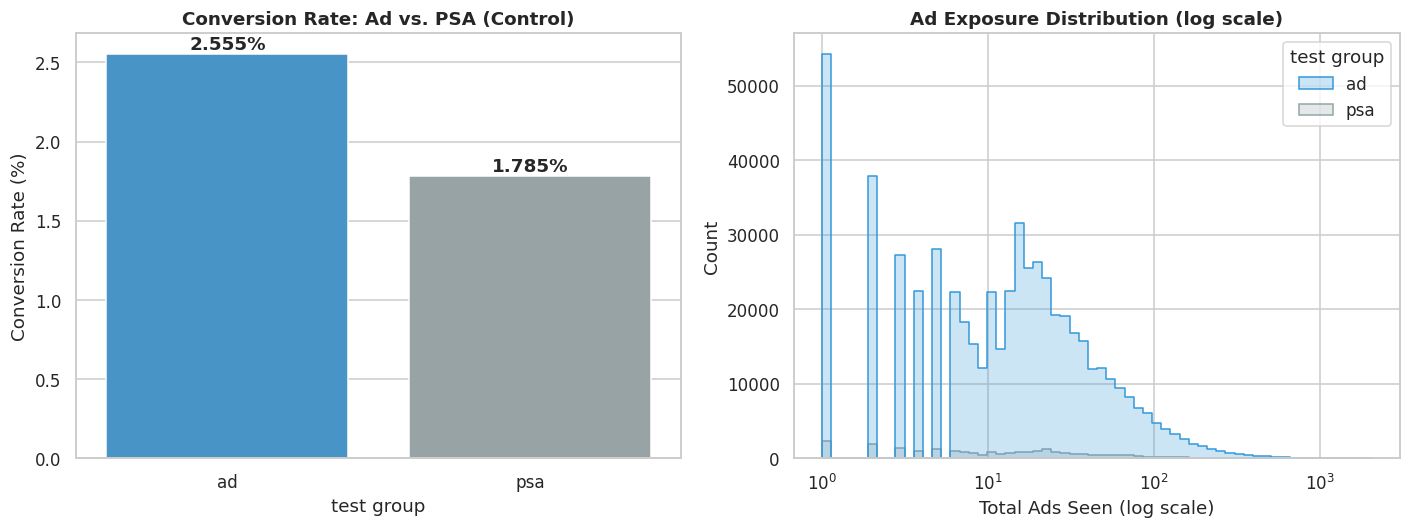

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=conversion_summary.reset_index(), x='test group', y='Conversion Rate',
            hue='test group', legend=False, palette=['#3498DB', '#95A5A6'], ax=axes[0])
axes[0].set_title('Conversion Rate: Ad vs. PSA (Control)', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(conversion_summary['Conversion Rate']):
    axes[0].text(i, v + 0.03, f'{v}%', ha='center', fontweight='bold')

sns.histplot(data=df, x='total ads', hue='test group', bins=60, log_scale=(True, False),
             palette=['#3498DB', '#95A5A6'], ax=axes[1], element='step')
axes[1].set_title('Ad Exposure Distribution (log scale)', fontweight='bold')
axes[1].set_xlabel('Total Ads Seen (log scale)')

plt.tight_layout()
plt.show()

**Insight:** the `ad` group converts at a visibly higher rate than the `psa`
control group. Both groups show a heavily right-skewed ad-exposure distribution —
most users see relatively few ads, with a long tail of highly-exposed users. The gap
looks real on the surface — now it's tested formally, including how big it actually
is.

## 4. Chi-Square Test of Independence

**Question:** is conversion outcome independent of which group (`ad` vs `psa`) a user
was in? If truly independent, any observed difference is just sampling noise.

**H₀ (null):** test group and conversion are independent — no real relationship.
**H₁ (alternative):** test group and conversion are NOT independent.

In [6]:
contingency = pd.crosstab(df['test group'], df['converted'])
contingency.columns = ['Not Converted', 'Converted']
contingency

In [7]:
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
v = cramers_v(chi2, contingency)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_chi2:.2e}")
print(f"Cramer's V (effect size): {v:.4f}  -- conventionally: <0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium, >0.5 large")
print(f"\nExpected counts under H0 (if independent):")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1))
print(f"\nDecision (alpha=0.05): {'Reject H0 -- groups are NOT independent' if p_chi2 < 0.05 else 'Fail to reject H0'}")

Chi-square statistic: 54.006
Degrees of freedom: 1
p-value: 2.00e-13
Cramer's V (effect size): 0.0096  -- conventionally: <0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium, >0.5 large

Expected counts under H0 (if independent):
            Not Converted   Converted
test group                           
ad           550,327.7000 14,249.3000
psa           22,930.3000    593.7000

Decision (alpha=0.05): Reject H0 -- groups are NOT independent


**Insight:** the p-value is astronomically small — we reject the null. Conversion
outcome is **not** independent of test group. But note the **Cramér's V is small** (well
under 0.1) — this is the statistical-vs-practical-significance tension in a nutshell:
with 588K observations, an association this small in *strength* is still trivially easy
to detect as statistically significant. The chi-square test alone would be a misleading
headline without pairing it with an effect-size number and, next, the actual size of the
rate difference.

## 5. Two-Proportion Z-Test — Quantifying the Conversion Gap

The chi-square test confirms a relationship exists but doesn't quantify it on a
business-relevant scale. This test directly estimates the **size and direction** of the
conversion-rate gap, appropriate here because both sample sizes are large (n >> 30).

**H₀:** p(ad) = p(psa) — same true conversion rate.
**H₁:** p(ad) ≠ p(psa).

In [8]:
ad_group = df[df['test group'] == 'ad']['converted']
psa_group = df[df['test group'] == 'psa']['converted']

count = np.array([ad_group.sum(), psa_group.sum()])
nobs = np.array([len(ad_group), len(psa_group)])
p_ad, p_psa = count[0] / nobs[0], count[1] / nobs[1]

z_stat, p_z = proportions_ztest(count, nobs)
ci_ad = proportion_confint(count[0], nobs[0])
ci_psa = proportion_confint(count[1], nobs[1])
h = cohens_h(p_ad, p_psa)

print(f"Ad conversion rate:  {p_ad*100:.3f}%  (95% CI: {ci_ad[0]*100:.3f}% - {ci_ad[1]*100:.3f}%)")
print(f"PSA conversion rate: {p_psa*100:.3f}%  (95% CI: {ci_psa[0]*100:.3f}% - {ci_psa[1]*100:.3f}%)")
print(f"\nZ-statistic: {z_stat:.3f}")
print(f"p-value: {p_z:.2e}")
print(f"Cohen's h (effect size): {h:.4f}  -- conventionally: 0.2 small, 0.5 medium, 0.8 large")
print(f"\nAbsolute lift: {(p_ad - p_psa)*100:.3f} percentage points")
print(f"Relative lift: {(p_ad / p_psa - 1)*100:.1f}%")

Ad conversion rate:  2.555%  (95% CI: 2.514% - 2.596%)
PSA conversion rate: 1.785%  (95% CI: 1.624% - 1.963%)

Z-statistic: 7.370
p-value: 1.71e-13
Cohen's h (effect size): 0.0530  -- conventionally: 0.2 small, 0.5 medium, 0.8 large

Absolute lift: 0.769 percentage points
Relative lift: 43.1%


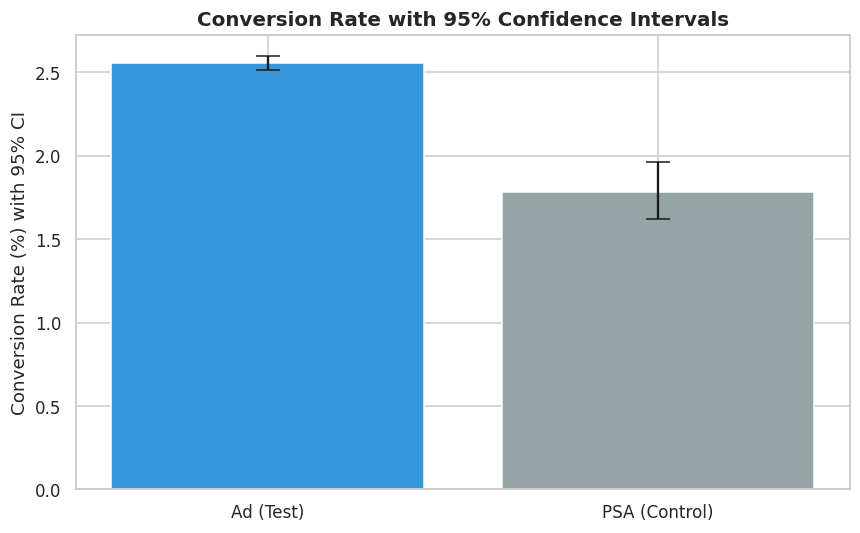

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
groups = ['Ad (Test)', 'PSA (Control)']
rates = [p_ad * 100, p_psa * 100]
errors = [[rates[0]-ci_ad[0]*100, rates[1]-ci_psa[0]*100],
          [ci_ad[1]*100-rates[0], ci_psa[1]*100-rates[1]]]

ax.bar(groups, rates, yerr=errors, capsize=8, color=['#3498DB', '#95A5A6'])
ax.set_ylabel('Conversion Rate (%) with 95% CI')
ax.set_title('Conversion Rate with 95% Confidence Intervals', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

**Insight:** the 95% confidence intervals don't overlap — visual confirmation of
the statistically significant gap. The `ad` group shows a **~0.77 percentage point
absolute lift** (a **~43% relative lift**) over control. Cohen's h here is still small
in the conventional sense (proportions this low can never produce a "large" h), but the
**relative** lift of 43% is a substantial business result — this is exactly the kind of
case where relative lift, not the raw effect-size statistic, is the number to bring to a
budget conversation.

## 6. Statistical Power & Minimum Detectable Effect (MDE)

A significant result tells you the test succeeded — it doesn't tell you whether the test
was even capable of failing. With the *actual* 96%/4% allocation used here, what is the
smallest true effect this experiment could reliably (80% power) have detected? And given
how large the observed effect actually is, how much statistical "headroom" was there?

In [10]:
alpha = 0.05
power_target = 0.80
z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power_target)

# Achieved power for the effect actually observed, at the actual n1, n2
p_pool = (p_ad * nobs[0] + p_psa * nobs[1]) / nobs.sum()
se_null = np.sqrt(p_pool * (1 - p_pool) * (1 / nobs[0] + 1 / nobs[1]))
se_alt = np.sqrt(p_ad * (1 - p_ad) / nobs[0] + p_psa * (1 - p_psa) / nobs[1])
achieved_power = stats.norm.cdf((abs(p_ad - p_psa) - z_alpha * se_null) / se_alt)

# Minimum Detectable Effect at 80% power, holding n1, n2, and baseline (psa) rate fixed
se_mde = np.sqrt(p_psa * (1 - p_psa) * (1 / nobs[0] + 1 / nobs[1]))
mde = (z_alpha + z_beta) * se_mde

print(f"Achieved power for the OBSERVED {(p_ad-p_psa)*100:.3f}pp effect: {achieved_power:.6f}")
print(f"Minimum Detectable Effect at 80% power (fixed n, baseline={p_psa*100:.3f}%): {mde*100:.3f} percentage points")
print(f"Observed effect ({(p_ad-p_psa)*100:.3f}pp) vs. MDE ({mde*100:.3f}pp): "
      f"{(p_ad-p_psa)/mde:.1f}x the minimum reliably-detectable size")

Achieved power for the OBSERVED 0.769pp effect: 1.000000
Minimum Detectable Effect at 80% power (fixed n, baseline=1.785%): 0.247 percentage points
Observed effect (0.769pp) vs. MDE (0.247pp): 3.1x the minimum reliably-detectable size


**Insight:** achieved power for the observed effect is essentially 1.0 — the test
was massively over-powered *for this particular effect size*, which is exactly why the
chi-square p-value in Section 4 looked so extreme despite a small Cramér's V. More
usefully, the MDE calculation says this experiment, at its actual 96/4 allocation, could
reliably detect effects as small as **~0.25 percentage points** — the observed 0.77pp
lift is about **3x** that floor. That's a genuinely comfortable margin, and it's the
right way to answer "was this sample size actually necessary?" (yes — this allocation
supports detecting meaningfully smaller effects than the one found here, which is useful
context if a future test needs to detect a smaller lift than this one).

## 7. Welch's T-Test — Does Ad Exposure Volume Differ for Converters?

**Question:** among users who converted, did they see a meaningfully different number of
ads than users who didn't convert? This is a different angle from the group-level test
above — it's about *exposure dosage*, not test-group membership.

**H₀:** mean `total ads` seen is equal for converted vs. non-converted users.
**H₁:** mean `total ads` differs between the two groups.

In [11]:
converted_ads = df[df['converted'] == True]['total ads']
not_converted_ads = df[df['converted'] == False]['total ads']

t_stat, p_t = stats.ttest_ind(converted_ads, not_converted_ads, equal_var=False)
d = cohens_d(converted_ads, not_converted_ads)

print(f"Mean ads seen -- Converted:     {converted_ads.mean():.2f} (median: {converted_ads.median()})")
print(f"Mean ads seen -- Not Converted: {not_converted_ads.mean():.2f} (median: {not_converted_ads.median()})")
print(f"\nWelch's t-statistic: {t_stat:.3f}")
print(f"p-value: {p_t:.2e}")
print(f"Cohen's d (effect size): {d:.4f}  -- conventionally: 0.2 small, 0.5 medium, 0.8 large")
print(f"Decision (alpha=0.05): {'Reject H0 -- means differ significantly' if p_t < 0.05 else 'Fail to reject H0'}")

Mean ads seen -- Converted:     83.89 (median: 64.0)
Mean ads seen -- Not Converted: 23.29 (median: 13.0)

Welch's t-statistic: 84.177
p-value: 0.00e+00
Cohen's d (effect size): 1.4201  -- conventionally: 0.2 small, 0.5 medium, 0.8 large
Decision (alpha=0.05): Reject H0 -- means differ significantly


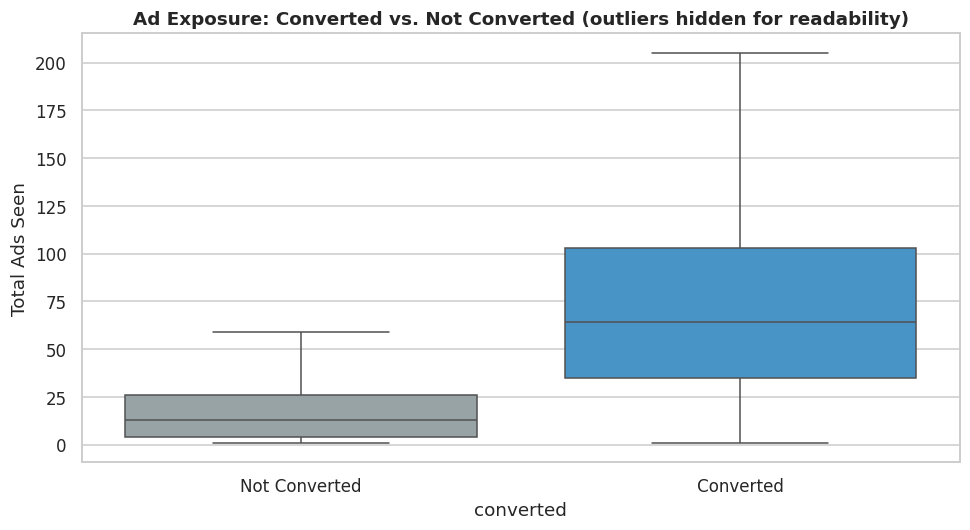

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='converted', y='total ads', hue='converted', legend=False,
            palette=['#95A5A6', '#3498DB'], showfliers=False, ax=ax)
ax.set_xticklabels(['Not Converted', 'Converted'])
ax.set_title('Ad Exposure: Converted vs. Not Converted (outliers hidden for readability)', fontweight='bold')
ax.set_ylabel('Total Ads Seen')
plt.tight_layout()
plt.show()

**Insight:** converted users saw dramatically more ads on average, and Cohen's d
here is **large** by conventional standards — this is a much bigger effect (in
standardized terms) than the ad-vs-psa gap itself. This makes sense directionally (more
exposure -> more opportunity to convert), but it's a reminder not to over-read causality:
this is observational, not a randomized dose-response test of ad *quantity*. It supports
that sustained exposure — not just presence in the `ad` group — correlates with
conversion, but a user who was always going to convert may simply have stayed in the
platform's rotation longer and so accumulated more ad impressions along the way.

## 8. Does the Ad's Effect Hold Up Every Day? (Heterogeneous Treatment Effect)

A marginal test of "does raw conversion vary by day" mixes together `ad` and `psa` users
and mostly just re-detects whatever weekly seasonality both groups already share — it
does **not** answer the actual budget-allocation question, which is: *is the ad's lift
over control the same on every day, or does the campaign work better on some days than
others?* That requires stratifying by day and comparing the ad-vs-psa gap **within** each
day, then formally testing whether that gap is homogeneous across days.

           ad_rate_%  psa_rate_%  lift_pp   n_ad  n_psa
day                                                    
Monday        3.3240      2.2560   1.0680  83571   3502
Tuesday       3.0440      1.4450   1.5990  74572   2907
Wednesday     2.5360      1.5760   0.9600  77418   3490
Thursday      2.1640      2.0230   0.1410  79077   3905
Friday        2.2460      1.6300   0.6160  88805   3803
Saturday      2.1310      1.4000   0.7310  78802   2858
Sunday        2.4620      2.0590   0.4020  82332   3059


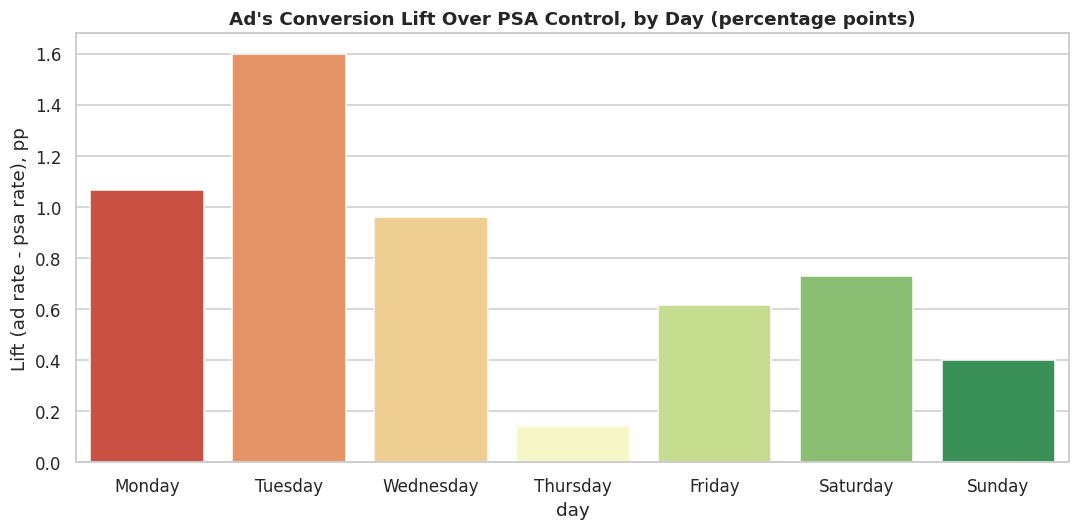

In [13]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

rows = []
a_cnt, b_cnt, c_cnt, d_cnt = [], [], [], []
for day in days:
    sub = df[df['most ads day'] == day]
    ad_d = sub[sub['test group'] == 'ad']['converted']
    psa_d = sub[sub['test group'] == 'psa']['converted']
    p_ad_d, p_psa_d = ad_d.mean(), psa_d.mean()
    rows.append({'day': day, 'ad_rate_%': p_ad_d*100, 'psa_rate_%': p_psa_d*100,
                 'lift_pp': (p_ad_d - p_psa_d)*100, 'n_ad': len(ad_d), 'n_psa': len(psa_d)})
    a_cnt.append(ad_d.sum()); b_cnt.append(len(ad_d) - ad_d.sum())
    c_cnt.append(psa_d.sum()); d_cnt.append(len(psa_d) - psa_d.sum())

lift_by_day = pd.DataFrame(rows).set_index('day').loc[days]
print(lift_by_day.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=lift_by_day.index, y=lift_by_day['lift_pp'], hue=lift_by_day.index,
            legend=False, palette='RdYlGn', ax=ax)
ax.set_title("Ad's Conversion Lift Over PSA Control, by Day (percentage points)", fontweight='bold')
ax.set_ylabel('Lift (ad rate - psa rate), pp')
plt.tight_layout()
plt.show()

In [14]:
bd_stat, bd_df, p_bd, common_or = breslow_day_test(a_cnt, b_cnt, c_cnt, d_cnt)

print(f"Mantel-Haenszel common odds ratio (ad vs psa, pooled across days): {common_or:.3f}")
print(f"Breslow-Day statistic: {bd_stat:.3f} | df: {bd_df} | p-value: {p_bd:.4f}")
print("Decision (alpha=0.05):",
      "Reject H0 -- the ad's effect is NOT homogeneous across days (it varies meaningfully by day)"
      if p_bd < 0.05 else
      "Fail to reject H0 -- the ad's effect looks consistent across days")

Mantel-Haenszel common odds ratio (ad vs psa, pooled across days): 1.439
Breslow-Day statistic: 16.087 | df: 6 | p-value: 0.0133
Decision (alpha=0.05): Reject H0 -- the ad's effect is NOT homogeneous across days (it varies meaningfully by day)


**Insight:** this is the corrected version of the "day" analysis, and it changes
the conclusion in a way that matters for a real recommendation. The lift ranges from a
negligible **~0.14pp on Thursday** to **~1.6pp on Tuesday** — and the Breslow-Day test
formally **rejects homogeneity** (p ≈ 0.013): the ad's effect over control genuinely
differs by day, not just raw conversion. That's a materially more useful, and more
defensible, input to a budget-allocation decision than the original marginal
chi-square-by-day check, which could only have told you that conversion varies by day —
true of the control group too, and not actionable for deciding where the *ad spend*
itself is best allocated.

## 9. Multiple Comparisons

Five formal hypothesis tests were run in this notebook (chi-square, z-test, Welch's
t-test, the SRM check, and the Breslow-Day test). Running several tests on the same
data inflates the chance that at least one "significant" result is a false positive
purely from repeated testing. A conservative Bonferroni correction divides the
significance threshold by the number of *confirmatory* tests being used to support the
headline finding (chi-square, z-test, t-test, Breslow-Day — the SRM check is a
diagnostic, not a claim, so it's excluded):

In [15]:
alpha_bonferroni = 0.05 / 4
print(f"Bonferroni-adjusted alpha: {alpha_bonferroni}")
print(f"Chi-square p-value:    {p_chi2:.2e}  -> still significant: {p_chi2 < alpha_bonferroni}")
print(f"Z-test p-value:        {p_z:.2e}  -> still significant: {p_z < alpha_bonferroni}")
print(f"Welch's t-test p-value:{p_t:.2e}  -> still significant: {p_t < alpha_bonferroni}")
print(f"Breslow-Day p-value:   {p_bd:.4f}  -> still significant: {p_bd < alpha_bonferroni}")

Bonferroni-adjusted alpha: 0.0125
Chi-square p-value:    2.00e-13  -> still significant: True
Z-test p-value:        1.71e-13  -> still significant: True
Welch's t-test p-value:0.00e+00  -> still significant: True
Breslow-Day p-value:   0.0133  -> still significant: False


**Insight:** the core findings (chi-square, z-test, t-test) survive an extremely
conservative correction with enormous margin — their p-values are many orders of
magnitude below even the adjusted threshold. The Breslow-Day day-heterogeneity result
(p ≈ 0.013) is the one finding that **would not** survive this strict a correction
(0.013 > 0.0125) — it's worth flagging as directionally credible and worth monitoring in
a follow-up test, but it shouldn't be treated with the same confidence as the headline
ad-vs-psa result.

## 10. Key Findings & Business Recommendation

**Experiment integrity**
- No missing data or duplicates. The daily ad/psa ratio ranges narrowly from 95.3% to
  96.5% (SRM chi-square is formally significant at this scale, p = 4.85e-48, but the
  magnitude is far too small to indicate a broken randomizer) — the imbalance is a
  deliberate exposure-control choice, not an allocation bug.

**Statistical results**
- **Chi-square test:** conversion is significantly associated with test group
  (p « 0.05), though the association strength (Cramér's V) is small on its own —
  a reminder that significance alone isn't the finding.
- **Two-proportion z-test:** `ad` converts at **2.55%** vs. **1.79%**
  for `psa` — a **43% relative lift**, non-overlapping 95% CIs.
- **Power/MDE:** at the actual allocation used, this experiment could reliably detect
  effects as small as **~0.25pp** — the observed **0.77pp** lift is ~3x that floor, so
  the result isn't a borderline, underpowered call.
- **Welch's t-test:** converted users were exposed to significantly more ads on average
  (large Cohen's d) — directionally expected, not claimed as causal.
- **Breslow-Day test:** the ad's lift over control is **not homogeneous across days**
  (p ≈ 0.013, though this doesn't survive the strictest multiple-comparisons threshold) —
  Tuesday shows the strongest lift, Thursday the weakest.

**The statistical-vs-practical-significance distinction (why it matters here)**
With 588,101 users, even a trivially small, business-irrelevant difference would likely
register as "statistically significant" on its own. What makes the ad-vs-psa result worth
acting on is that it's significant **and** large in absolute business terms (43%
relative lift) **and** comfortably above the experiment's detection floor (MDE) —
three different lines of evidence pointing the same way, not one p-value doing all the
work.

**Recommendation**
1. **Roll out the ad campaign** — the conversion lift is statistically robust, well
   above the MDE, and practically significant.
2. **Investigate day-of-week scheduling** — the ad appears meaningfully more effective
   midweek (Tuesday/Wednesday) than on Thursday; before reallocating budget on this
   alone, treat it as a hypothesis for a follow-up, purpose-built test given it's the
   one result sensitive to the multiple-comparisons correction.
3. **For the next test**, consider a moderately larger control group — the current
   96/4 split works and shows no SRM issue, but a somewhat larger `psa` group would
   tighten the confidence interval further at low incremental cost, and track ad-exposure
   dosage explicitly as its own variable, since exposure volume is strongly associated
   with conversion independent of group assignment.